# Task 1: Data Scraping

The dataset was scraped using Scrapy.

The spider:
- Crawled the first five catalog pages.
- Visited every book page.
- Extracted title, category, price, rating, availability,
  product description, UPC, number of reviews,
  and product URL.
- Exported the data to books.csv.

In [5]:
!scrapy crawl books -O books.csv

2026-08-06 19:55:11 [scrapy.utils.log] INFO: Scrapy 2.17.0 started (bot: bookscraper)
2026-08-06 19:55:11 [scrapy.utils.log] INFO: Versions:
{'lxml': '6.0.1',
 'libxml2': '2.11.9',
 'cssselect': '1.5.0',
 'parsel': '1.11.0',
 'w3lib': '2.4.1',
 'Twisted': '26.4.0',
 'Python': '3.10.11 (tags/v3.10.11:7d4cc5a, Apr  5 2023, 00:38:17) [MSC v.1929 '
           '64 bit (AMD64)]',
 'pyOpenSSL': '26.4.0 (OpenSSL 4.0.1 9 Jun 2026)',
 'cryptography': '50.0.0',
 'Platform': 'Windows-10-10.0.26200-SP0'}
2026-08-06 19:55:11 [scrapy.crawler] DEBUG: Using AsyncCrawlerProcess
2026-08-06 19:55:11 [asyncio] DEBUG: Using selector: SelectSelector
2026-08-06 19:55:11 [scrapy.addons] INFO: Enabled addons:
[]
2026-08-06 19:55:11 [scrapy.utils.log] DEBUG: Using reactor: twisted.internet.asyncioreactor.AsyncioSelectorReactor
2026-08-06 19:55:11 [scrapy.utils.log] DEBUG: Using asyncio event loop: asyncio.windows_events._WindowsSelectorEventLoop
2026-08-06 19:55:11 [scrapy.extensions.telnet] INFO: Telnet Passwor

In [2]:
import pandas as pd

df = pd.read_csv("books.csv")

df.head()

,title,category,price,rating,availability,product_description,UPC,number_of_reviews,product_url
0,It's Only the Himalayas,Travel,£45.17,Two,In stock (19 available),"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,£51.33,Two,In stock (19 available),Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,One,In stock (19 available),"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,£23.88,One,In stock (19 available),"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,Three,In stock (19 available),This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...


In [3]:
print("Total Books:", len(df))

Total Books: 100


In [4]:
df.isnull().sum()

title                  0
category               0
price                  0
rating                 0
availability           0
product_description    0
UPC                    0
number_of_reviews      0
product_url            0
dtype: int64

In [5]:
df["UPC"].duplicated().sum()

np.int64(0)

In [6]:
print("Shape:", df.shape)

df.info()

Shape: (100, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   title                100 non-null    object
 1   category             100 non-null    object
 2   price                100 non-null    object
 3   rating               100 non-null    object
 4   availability         100 non-null    object
 5   product_description  100 non-null    object
 6   UPC                  100 non-null    object
 7   number_of_reviews    100 non-null    int64 
 8   product_url          100 non-null    object
dtypes: int64(1), object(8)
memory usage: 7.2+ KB


In [7]:
print("Missing Values:")

df.isnull().sum()

Missing Values:


title                  0
category               0
price                  0
rating                 0
availability           0
product_description    0
UPC                    0
number_of_reviews      0
product_url            0
dtype: int64

In [8]:
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("After removing duplicates:", df.shape)

Duplicate Rows: 0
After removing duplicates: (100, 9)


In [9]:
df["price"] = (
    df["price"]
    .str.replace("£", "", regex=False)
    .astype(float)
)

df["price"].head()

0    45.17
1    51.33
2    37.59
3    23.88
4    57.25
Name: price, dtype: float64

In [10]:
df["availability"] = (
    df["availability"]
    .str.extract(r'(\d+)')
    .astype(int)
)

df["availability"].head()

0    19
1    19
2    19
3    19
4    19
Name: availability, dtype: int64

In [11]:
df["number_of_reviews"] = df["number_of_reviews"].astype(int)

df["number_of_reviews"].head()

0    0
1    0
2    0
3    0
4    0
Name: number_of_reviews, dtype: int64

In [12]:
print(df["rating"].unique())

['Two' 'One' 'Three' 'Five' 'Four']


In [13]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["rating"] = df["rating"].map(rating_map)

df["rating"].head()

0    2
1    2
2    1
3    1
4    3
Name: rating, dtype: int64

In [14]:
df.dtypes

title                   object
category                object
price                  float64
rating                   int64
availability             int64
product_description     object
UPC                     object
number_of_reviews        int64
product_url             object
dtype: object

In [15]:
text_columns = [
    "title",
    "category",
    "product_description",
    "UPC",
    "product_url"
]

for col in text_columns:
    df[col] = df[col].astype(str).str.strip()

df.head()

,title,category,price,rating,availability,product_description,UPC,number_of_reviews,product_url
0,It's Only the Himalayas,Travel,45.17,2,19,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,51.33,2,19,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,37.59,1,19,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,23.88,1,19,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,57.25,3,19,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...


In [16]:
def price_category(price):
    if price < 20:
        return "Low"
    elif price < 35:
        return "Medium"
    else:
        return "High"

df["price_category"] = df["price"].apply(price_category)

df[["price", "price_category"]].head()

,price,price_category
0,45.17,High
1,51.33,High
2,37.59,High
3,23.88,Medium
4,57.25,High


In [17]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df["category_encoded"] = encoder.fit_transform(df["category"])

df[["category", "category_encoded"]].head()

,category,category_encoded
0,Travel,27
1,Politics,19
2,Science Fiction,22
3,Poetry,18
4,Music,13


In [18]:
category_mapping = pd.DataFrame({
    "Category": encoder.classes_,
    "Encoded Value": range(len(encoder.classes_))
})

category_mapping

,Category,Encoded Value
0,Add a comment,0
1,Art,1
2,Business,2
3,Childrens,3
4,Contemporary,4
5,Default,5
6,Fantasy,6
7,Fiction,7
8,Food and Drink,8
9,Health,9


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                100 non-null    object 
 1   category             100 non-null    object 
 2   price                100 non-null    float64
 3   rating               100 non-null    int64  
 4   availability         100 non-null    int64  
 5   product_description  100 non-null    object 
 6   UPC                  100 non-null    object 
 7   number_of_reviews    100 non-null    int64  
 8   product_url          100 non-null    object 
 9   price_category       100 non-null    object 
 10  category_encoded     100 non-null    int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 8.7+ KB


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [21]:
# Replace invalid category with "Not Available"
df["category"] = df["category"].replace("Not Available","Add a comment")

# Verify the replacement
print(df["category"].unique())

['Travel' 'Politics' 'Science Fiction' 'Poetry' 'Music' 'Sequential Art'
 'Young Adult' 'Default' 'Business' 'History' 'Thriller' 'Mystery'
 'Philosophy' 'Childrens' 'Nonfiction' 'Spirituality' 'Art' 'Romance'
 'Food and Drink' 'Add a comment' 'Fiction' 'Fantasy' 'Contemporary'
 'New Adult' 'Horror' 'Health' 'Self Help' 'Science' 'Historical Fiction']


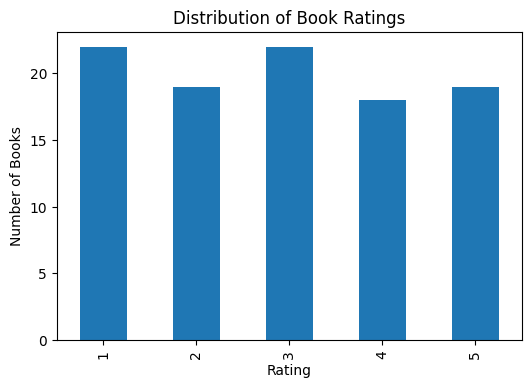

In [22]:
rating_counts = df["rating"].value_counts().sort_index()

plt.figure(figsize=(6,4))
rating_counts.plot(kind="bar")

plt.title("Distribution of Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")

plt.show()

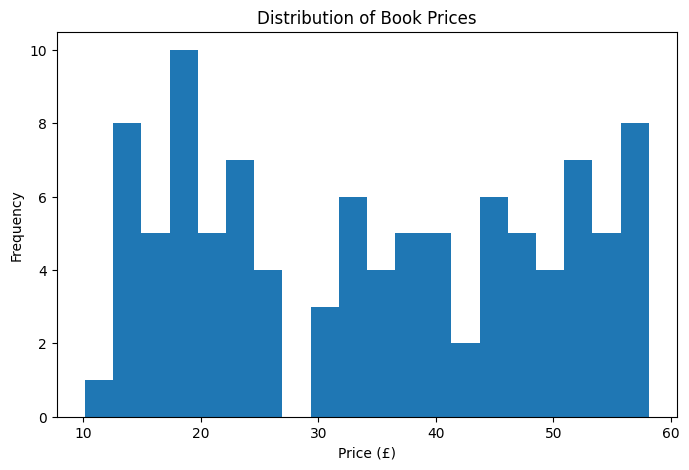

In [23]:
plt.figure(figsize=(8,5))

plt.hist(df["price"], bins=20)

plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")

plt.show()

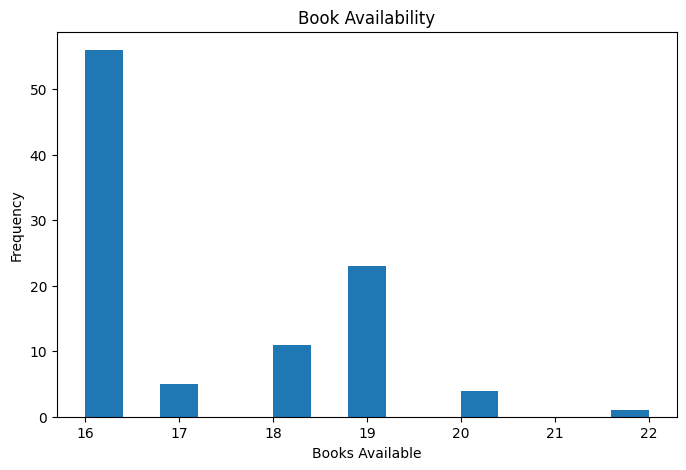

In [24]:
plt.figure(figsize=(8,5))

plt.hist(df["availability"], bins=15)

plt.title("Book Availability")
plt.xlabel("Books Available")
plt.ylabel("Frequency")

plt.show()

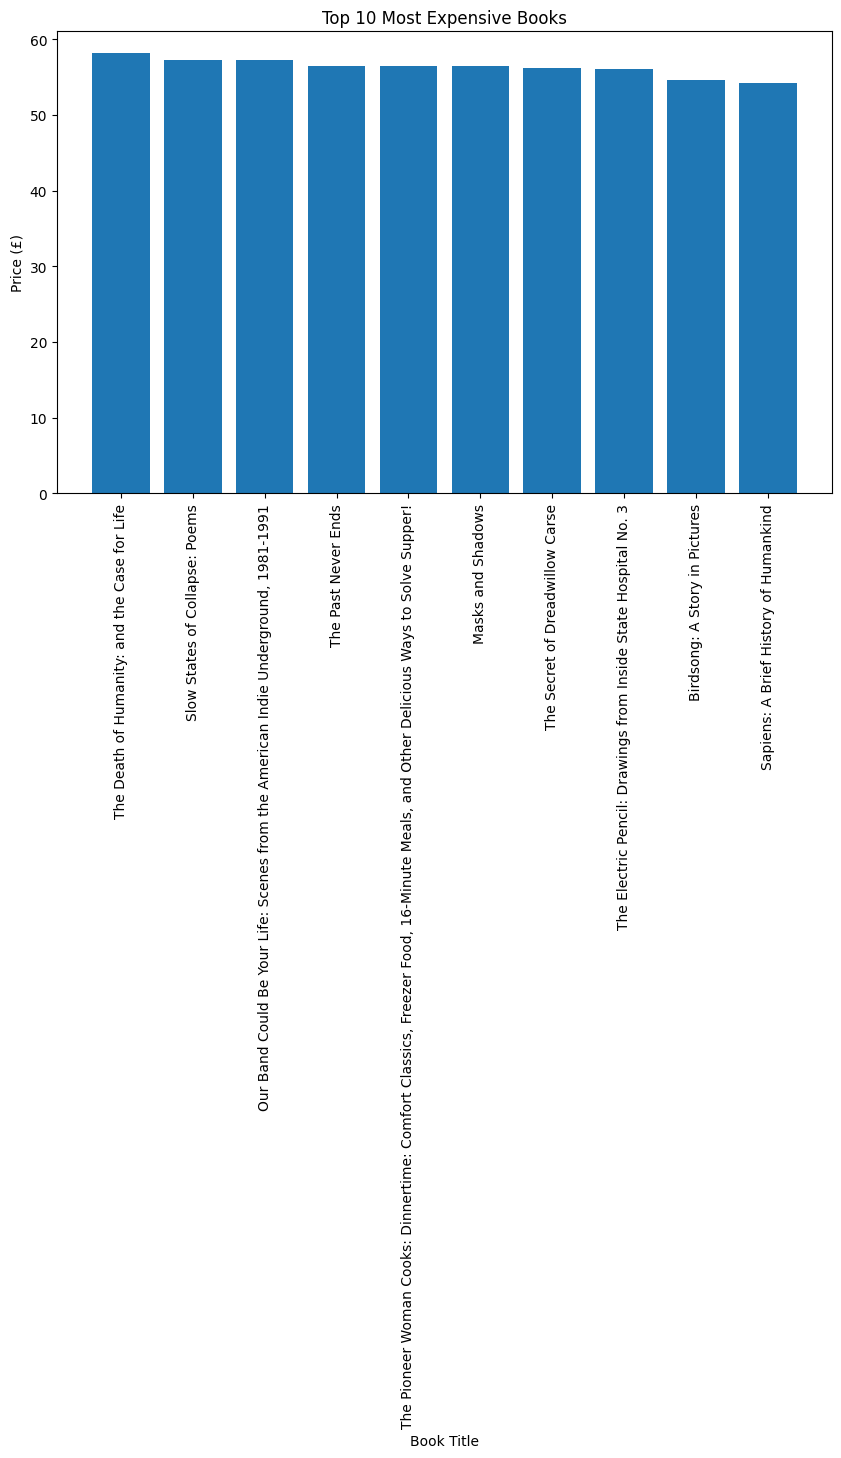

In [25]:
top10 = df.nlargest(10, "price")

plt.figure(figsize=(10,6))

plt.bar(top10["title"], top10["price"])

plt.title("Top 10 Most Expensive Books")
plt.xlabel("Book Title")
plt.ylabel("Price (£)")
plt.xticks(rotation=90)

plt.show()

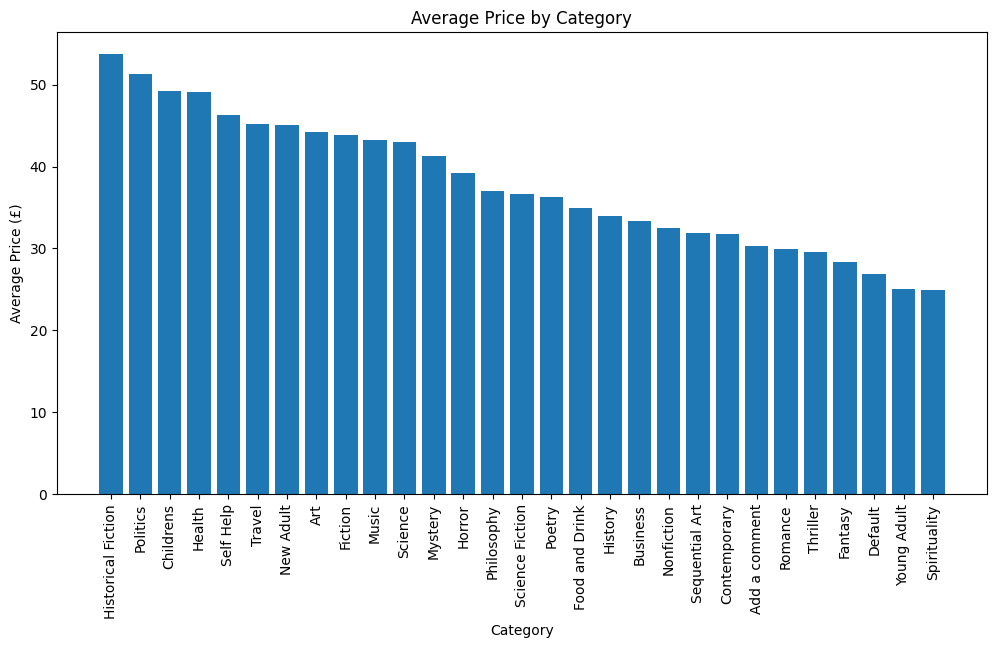

In [26]:
avg_price = (
    df.groupby("category")["price"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

plt.bar(avg_price.index, avg_price.values)

plt.title("Average Price by Category")
plt.xlabel("Category")
plt.ylabel("Average Price (£)")
plt.xticks(rotation=90)

plt.show()

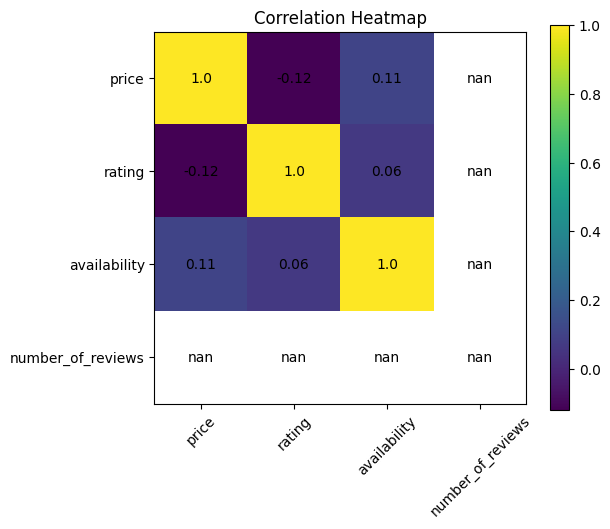

In [27]:
correlation = df[
    [
        "price",
        "rating",
        "availability",
        "number_of_reviews"
    ]
].corr()

plt.figure(figsize=(6,5))

plt.imshow(correlation)

plt.colorbar()

plt.xticks(range(len(correlation.columns)), correlation.columns, rotation=45)
plt.yticks(range(len(correlation.columns)), correlation.columns)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(j, i, round(correlation.iloc[i, j], 2),
                 ha="center", va="center")

plt.title("Correlation Heatmap")

plt.show()

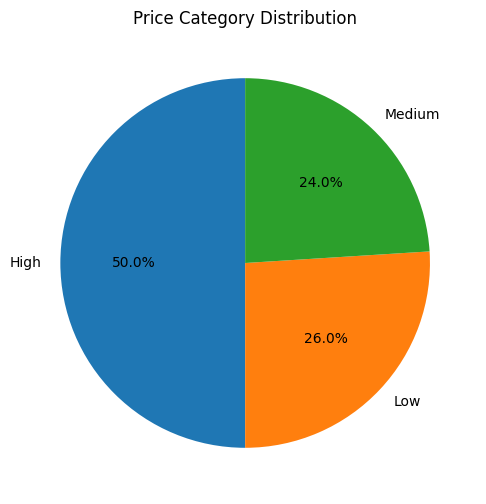

In [28]:
price_counts = df["price_category"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    price_counts,
    labels=price_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Price Category Distribution")

plt.show()

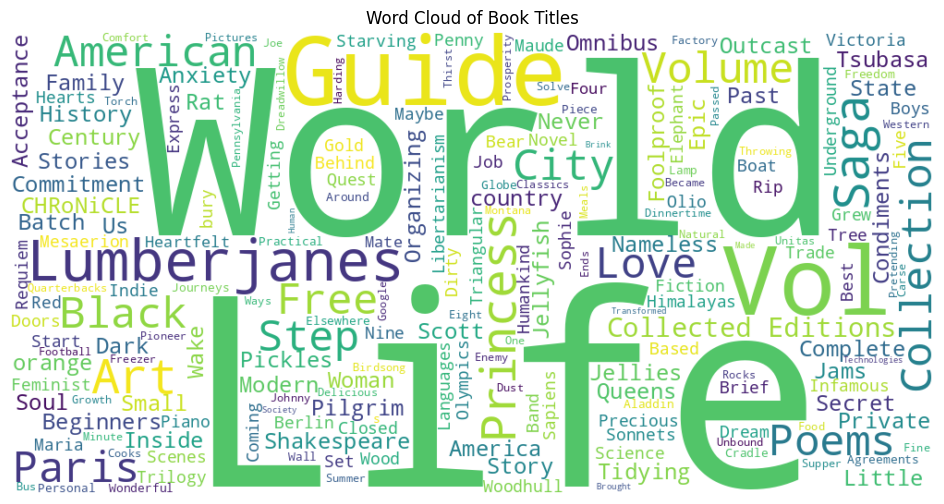

In [29]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all book titles into one string
text = " ".join(df["title"].dropna())

# Generate word cloud
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

# Display
plt.figure(figsize=(14,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Book Titles")
plt.show()

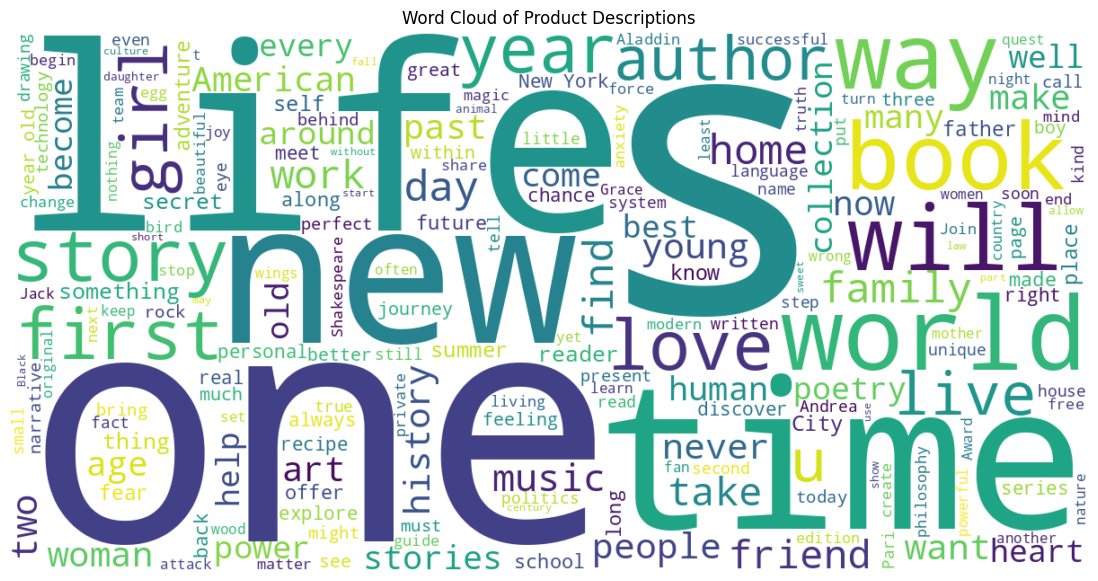

In [30]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Combine all descriptions
text = " ".join(df["product_description"].fillna(""))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Product Descriptions")
plt.show()

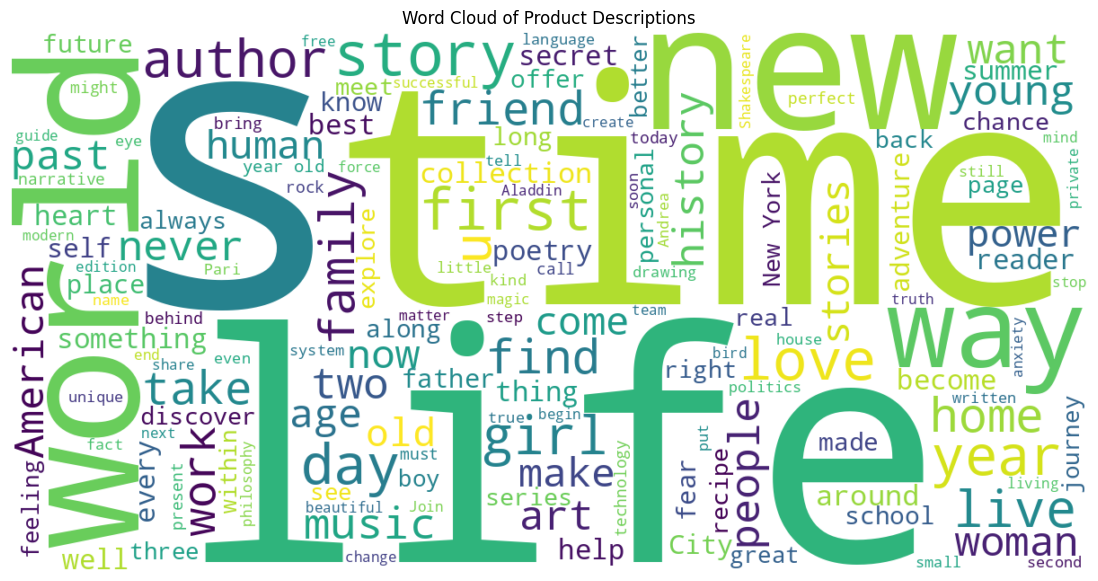

In [32]:
from wordcloud import WordCloud, STOPWORDS

stopwords = set(STOPWORDS)
stopwords.update([
    "book", "books", "read", "one", "will", "can",
    "also", "said", "like", "much", "many"
])

text = " ".join(df["product_description"].fillna(""))

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    stopwords=stopwords,
    max_words=150
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Product Descriptions")
plt.show()

Looking at the genres, the distribution is pretty uneven. Sequential Art takes the top spot with 14 books, followed closely by Nonfiction at 12 and Default at 9. On the flip side, several genres—like Business, Politics, Science, and Travel—only have a single book representing them.

Prices are all over the place, spanning from roughly £10 up to nearly £60. The average cost shifts quite a bit from one category to the next, which shows that certain genres just tend to be pricier than others. Exactly half of the dataset (50.0%) falls into the High price category, while the rest is split fairly evenly between Low (26.0%) and Medium (24.0%).

The correlation data shows there is almost zero connection between how much a book costs and the rating it gets. Expensive books aren't guaranteed to get better reviews, which basically means a higher price tag doesn't equal a happier reader.

Inventory levels are all over the map. A few books are running incredibly low with just a handful of copies left, while others have plenty of stock sitting on the shelves.

There are books that scored 4 or 5 stars but still carry a lower price tag. They give readers great quality without spending too much, making them the easiest recommendations to make.

The dataset is heavily skewed toward a few genres, we have to be careful with our conclusions. The categories with only one or two books don't give us enough data to make fair comparisons, whereas the heavily populated genres give us a much clearer, more reliable picture.

Takeaway on data:
I only scraped the first five pages of the website, giving us a hard limit of 100 books, This does not represent the site's complete catalogue. And it only have generic star ratings to go on, not detailed customer scores. Almost none of the books have actual written reviews, which leaves us in the dark about reader opinions. Prices and stock numbers fluctuate constantly, so this data will get outdated.